In [6]:
import numpy as np
X = np.array([
    [1.0, 1.0],
    [1.5, 2.0],
    [3.0, 4.0],
    [5.0, 7.0],
    [3.5, 5.0],
    [4.5, 5.0],
    [3.5, 4.5]
])    
k = 2  
centroids = X[np.random.choice(range(len(X)), k, replace=False)]
print("Initial Centroids:\n", centroids)
for iteration in range(10):  
    distances = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X])
    labels = np.argmin(distances, axis=1) 
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
    print(f"\nIteration {iteration + 1}")
    print("Labels:", labels)
    print("Updated Centroids:\n", new_centroids)
    if np.allclose(centroids, new_centroids):
        print("\nConverged!")
        break
    centroids = new_centroids
print("\nFinal Centroids:\n", centroids)
print("Final Labels:", labels)

Initial Centroids:
 [[5.  7. ]
 [1.5 2. ]]

Iteration 1
Labels: [1 1 1 0 0 0 0]
Updated Centroids:
 [[4.125      5.375     ]
 [1.83333333 2.33333333]]

Iteration 2
Labels: [1 1 0 0 0 0 0]
Updated Centroids:
 [[3.9  5.1 ]
 [1.25 1.5 ]]

Iteration 3
Labels: [1 1 0 0 0 0 0]
Updated Centroids:
 [[3.9  5.1 ]
 [1.25 1.5 ]]

Converged!

Final Centroids:
 [[3.9  5.1 ]
 [1.25 1.5 ]]
Final Labels: [1 1 0 0 0 0 0]


Cluster Centers:
 [[6.97891189 2.27553431]
 [2.1989896  5.12548821]
 [7.84764626 7.5896299 ]]
Labels: [2 2 0 1 1 1 1 1 2 2 2 0 1 2 2 2 1 2 0 2 1 1 1 1 2 1 1 1 1 2 1 1 2 1 1 2 1
 0 1 2 1 0 1 0 2 2 2 0 2 2 0 2 0 2 0 0 1 1 1 1 0 0 2 1 1 2 0 2 0 0 0 1 1 1
 2 1 0 1 1 2 1 2 0 1 0 2 2 0 2 1 1 1 1 1 1 1 1 0 1 0]


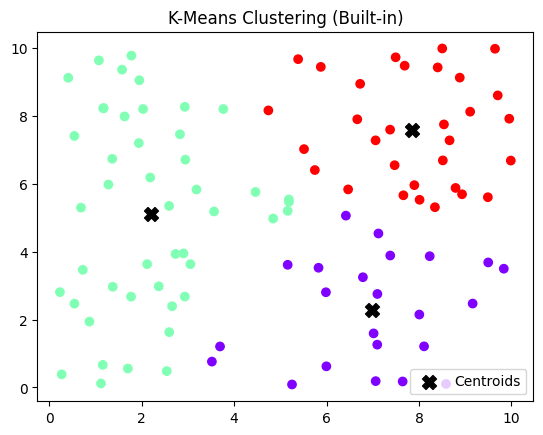

In [16]:


from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

X_large = np.random.rand(100, 2) * 10

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_large)

print("Cluster Centers:\n", kmeans.cluster_centers_)
print("Labels:", kmeans.labels_)


plt.scatter(X_large[:, 0], X_large[:, 1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='X', s=100, label='Centroids')
plt.title("K-Means Clustering (Built-in)")
plt.legend()
plt.show()


In [8]:


import numpy as np


X = np.array([
    [1, 1],
    [2, 1],
    [4, 3],
    [5, 4]
])

def euclidean(a, b):
    return np.sqrt(np.sum((a - b)**2))


n = len(X)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = euclidean(X[i], X[j])
np.fill_diagonal(dist_matrix, np.inf)

print("Initial Distance Matrix:\n", dist_matrix)


clusters = [[i] for i in range(n)]


while len(clusters) > 1:
   
    min_dist = np.inf
    pair = None
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
           
            d = np.min([dist_matrix[p1][p2] for p1 in clusters[i] for p2 in clusters[j]])
            if d < min_dist:
                min_dist = d
                pair = (i, j)

    print(f"\nMerging clusters {clusters[pair[0]]} and {clusters[pair[1]]} at distance {min_dist}")

 
    new_cluster = clusters[pair[0]] + clusters[pair[1]]
    clusters = [c for idx, c in enumerate(clusters) if idx not in pair]
    clusters.append(new_cluster)

    print("Current Clusters:", clusters)


Initial Distance Matrix:
 [[       inf 1.         3.60555128 5.        ]
 [1.                inf 2.82842712 4.24264069]
 [3.60555128 2.82842712        inf 1.41421356]
 [5.         4.24264069 1.41421356        inf]]

Merging clusters [0] and [1] at distance 1.0
Current Clusters: [[2], [3], [0, 1]]

Merging clusters [2] and [3] at distance 1.4142135623730951
Current Clusters: [[0, 1], [2, 3]]

Merging clusters [0, 1] and [2, 3] at distance 2.8284271247461903
Current Clusters: [[0, 1, 2, 3]]


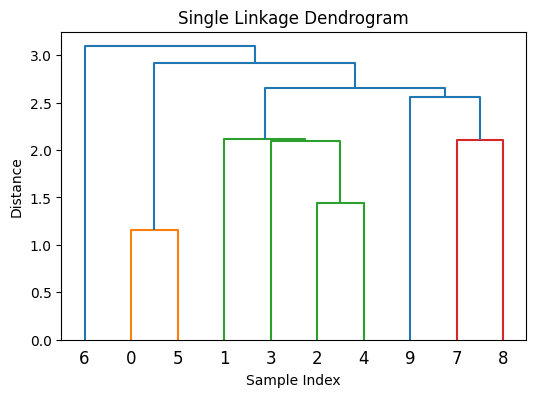

Cluster Labels: [1 1 1 1 1 1 1 1 1 1]


In [9]:


from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import numpy as np


X_large = np.random.rand(10, 2) * 10


Z = linkage(X_large, method='single')


plt.figure(figsize=(6, 4))
dendrogram(Z)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


threshold = 5.0
clusters = fcluster(Z, t=threshold, criterion='distance')
print("Cluster Labels:", clusters)


In [10]:

import numpy as np


X = np.array([
    [1, 1],
    [2, 1],
    [4, 3],
    [5, 4]
])


def euclidean(a, b):
    return np.sqrt(np.sum((a - b)**2))

n = len(X)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = euclidean(X[i], X[j])
np.fill_diagonal(dist_matrix, np.inf)

print("Initial Distance Matrix:\n", dist_matrix)


clusters = [[i] for i in range(n)]


while len(clusters) > 1:
    min_dist = np.inf
    pair = None
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
           
            d = np.max([dist_matrix[p1][p2] for p1 in clusters[i] for p2 in clusters[j]])
            if d < min_dist:
                min_dist = d
                pair = (i, j)

    print(f"\nMerging clusters {clusters[pair[0]]} and {clusters[pair[1]]} at distance {min_dist}")

   
    new_cluster = clusters[pair[0]] + clusters[pair[1]]
    clusters = [c for idx, c in enumerate(clusters) if idx not in pair]
    clusters.append(new_cluster)

    print("Current Clusters:", clusters)


Initial Distance Matrix:
 [[       inf 1.         3.60555128 5.        ]
 [1.                inf 2.82842712 4.24264069]
 [3.60555128 2.82842712        inf 1.41421356]
 [5.         4.24264069 1.41421356        inf]]

Merging clusters [0] and [1] at distance 1.0
Current Clusters: [[2], [3], [0, 1]]

Merging clusters [2] and [3] at distance 1.4142135623730951
Current Clusters: [[0, 1], [2, 3]]

Merging clusters [0, 1] and [2, 3] at distance 5.0
Current Clusters: [[0, 1, 2, 3]]


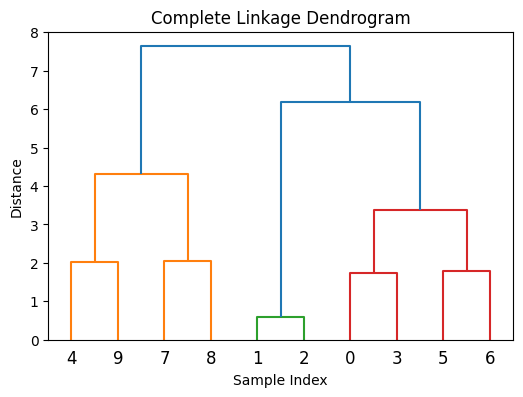

Cluster Labels: [3 2 2 3 1 3 3 1 1 1]


In [11]:


from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import numpy as np


X_large = np.random.rand(10, 2) * 10

Z = linkage(X_large, method='complete')


plt.figure(figsize=(6, 4))
dendrogram(Z)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


threshold = 5.0
clusters = fcluster(Z, t=threshold, criterion='distance')
print("Cluster Labels:", clusters)
